ALS subjects: 79
Control subjects: 61
ALS NaN count: 0
Control NaN count: 0

ALS feature shape: (79, 46)
Control feature shape: (61, 46)
ALS NaN count: 0
Control NaN count: 0

Accuracy: 0.9357
AUC: 0.9747

Sample Control Risk Scores:
Control 0: Risk = 0.6886
Control 1: Risk = 0.6520
Control 2: Risk = 0.7145
Control 3: Risk = 0.6303
Control 4: Risk = 0.7199
Control 5: Risk = 0.0017
Control 6: Risk = 0.6735
Control 7: Risk = 0.0001
Control 8: Risk = 0.6930
Control 9: Risk = 0.4593

Control Stage Distribution:
Healthy: 30
Presymptomatic: 21
ALS-like High Risk: 10


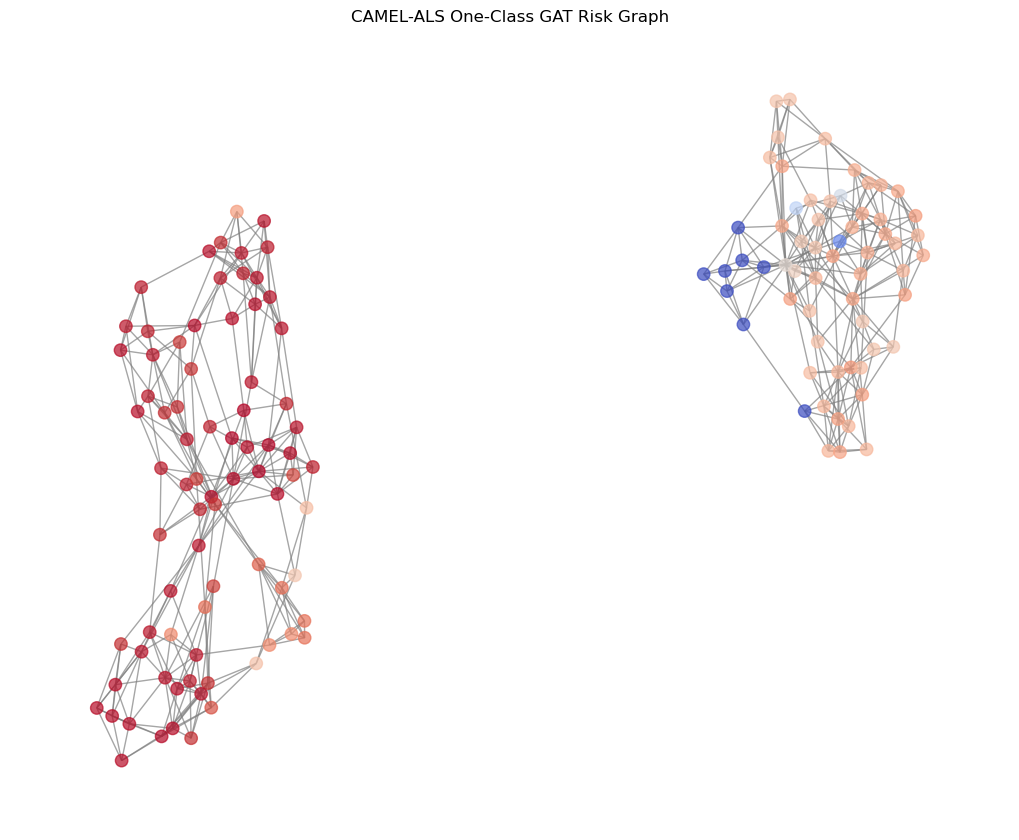

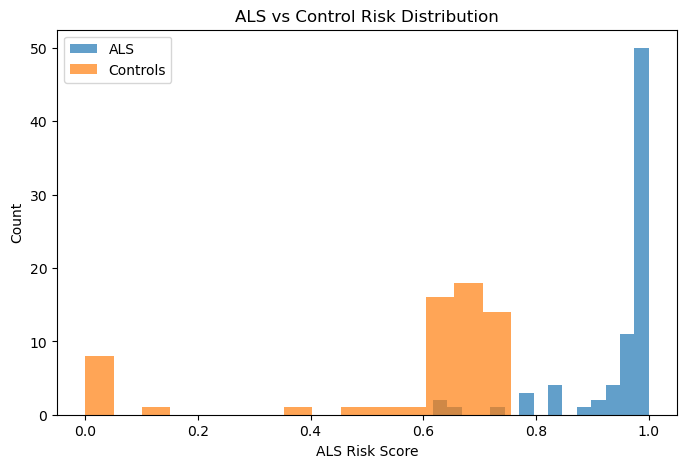

In [1]:
# ============================================================
# CAMEL-ALS: One-Class ALS Manifold Learning with GAT
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

from torch_geometric.data import Data
from torch_geometric.nn import GATConv
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv(r"multimodal_patient_level.csv")
df.replace([-9999, -8888, "N/D"], np.nan, inplace=True)
# ============================================================
# FEATURE EXTRACTION + CLEANING (FULL FIX)
# ============================================================

import numpy as np
import pandas as pd

# ============================================================
# 1. SEPARATE ALS AND CONTROLS
# ============================================================

is_als = df["Subject Group"].str.contains(
    "ALS",
    case=False,
    na=False
)

is_control = df["Subject Group"].str.contains(
    "Non-Neurological Control",
    case=False,
    na=False
)

als_df = df[is_als].copy()
control_df = df[is_control].copy()

print("ALS subjects:", len(als_df))
print("Control subjects:", len(control_df))

# ============================================================
# 2. FEATURE MATRIX
# ============================================================

drop_cols = ["Subject Group"]

X_als = als_df.drop(columns=drop_cols, errors="ignore")
X_control = control_df.drop(columns=drop_cols, errors="ignore")

# keep only numeric columns
X_als = X_als.select_dtypes(include=[np.number])
X_control = X_control.select_dtypes(include=[np.number])

# ============================================================
# 3. HANDLE NaN / INF VALUES
# ============================================================

X_als = X_als.replace([np.inf, -np.inf], np.nan)
X_control = X_control.replace([np.inf, -np.inf], np.nan)

# mean imputation
X_als = X_als.fillna(X_als.mean())
X_control = X_control.fillna(X_control.mean())

# final safety
X_als = X_als.fillna(0)
X_control = X_control.fillna(0)

print("ALS NaN count:", X_als.isna().sum().sum())
print("Control NaN count:", X_control.isna().sum().sum())

# ============================================================
# 4. VERIFY SHAPES
# ============================================================

print("\nALS feature shape:", X_als.shape)
print("Control feature shape:", X_control.shape)
# ============================================================
# 3. FEATURE MATRIX (CORRECTED)
# ============================================================
drop_cols = ["Subject Group"]

X_als = als_df.drop(columns=drop_cols, errors="ignore")
X_control = control_df.drop(columns=drop_cols, errors="ignore")

# keep only numeric columns
X_als = X_als.select_dtypes(include=[np.number])
X_control = X_control.select_dtypes(include=[np.number])

# ============================================================
# HANDLE NaN / INF VALUES  (VERY IMPORTANT)
# ============================================================

# replace inf values
X_als = X_als.replace([np.inf, -np.inf], np.nan)
X_control = X_control.replace([np.inf, -np.inf], np.nan)

# fill missing values using column mean
X_als = X_als.fillna(X_als.mean())
X_control = X_control.fillna(X_control.mean())

# final safety
X_als = X_als.fillna(0)
X_control = X_control.fillna(0)

print("ALS NaN count:", X_als.isna().sum().sum())
print("Control NaN count:", X_control.isna().sum().sum())
# ============================================================
# 4. NORMALIZATION
# ============================================================
scaler = StandardScaler()

X_als_scaled = scaler.fit_transform(X_als)
X_control_scaled = scaler.transform(X_control)

# ============================================================
# 5. COMBINE DATA
# ============================================================
X_all = np.vstack([X_als_scaled, X_control_scaled])

# labels only for evaluation
y = np.array([1]*len(X_als_scaled) + [0]*len(X_control_scaled))

X_tensor = torch.tensor(X_all, dtype=torch.float)

# ============================================================
# 6. GRAPH CONSTRUCTION (kNN cosine graph)
# ============================================================
sim = cosine_similarity(X_all)

edge_index = []

k = 6

for i in range(len(X_all)):
    neighbors = np.argsort(sim[i])[-k:]

    for j in neighbors:
        if i != j:
            edge_index.append([i, j])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

# ============================================================
# 7. CREATE GRAPH DATA
# ============================================================
data = Data(
    x=X_tensor,
    edge_index=edge_index
)

# ============================================================
# 8. GAT MODEL
# ============================================================
class GAT(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.gat1 = GATConv(in_channels, 32, heads=4, dropout=0.2)
        self.gat2 = GATConv(128, 32, heads=2, concat=True, dropout=0.2)

        self.lin = torch.nn.Linear(64, 16)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))

        z = self.lin(x)

        return z

model = GAT(X_all.shape[1])

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005,
    weight_decay=1e-3
)

# ============================================================
# 9. ONE-CLASS ALS TRAINING
# ============================================================
als_mask = torch.tensor(
    [True]*len(X_als_scaled) + [False]*len(X_control_scaled)
)

# learn ALS manifold centroid
for epoch in range(200):

    model.train()

    optimizer.zero_grad()

    z = model(data)

    z_als = z[als_mask]

    centroid = z_als.mean(dim=0)

    # minimize ALS embedding spread
    loss = ((z_als - centroid)**2).mean()

    loss.backward()
    optimizer.step()

# ============================================================
# 10. INFERENCE
# ============================================================
model.eval()

with torch.no_grad():

    z = model(data)

    z_als = z[als_mask]

    centroid = z_als.mean(dim=0)

    # distance to ALS centroid
    dist = torch.norm(z - centroid, dim=1)

    # convert to risk score
    dist_np = dist.numpy()
    sigma = np.std(dist_np)
    risk = np.exp(-(dist_np**2) / (2 * sigma**2))
# normalize to 0-1
risk = (risk - risk.min()) / (risk.max() - risk.min())
# ============================================================
# 11. EVALUATION
# ============================================================
pred = (risk > np.median(risk)).astype(int)

acc = accuracy_score(y, pred)
auc = roc_auc_score(y, risk)

print("\n==============================")
print("Accuracy:", round(acc, 4))
print("AUC:", round(auc, 4))
print("==============================")

# ============================================================
# 12. CONTROL PRESYMPTOMATIC RISK
# ============================================================
control_risk = risk[len(X_als_scaled):]

print("\nSample Control Risk Scores:")
for i in range(min(10, len(control_risk))):
    print(f"Control {i}: Risk = {control_risk[i]:.4f}")

# ============================================================
# 13. CLINICAL STAGING
# ============================================================
theta1 = np.quantile(control_risk, 0.50)
theta2 = np.quantile(control_risk, 0.85)

def stage_fn(r):

    if r < theta1:
        return 0   # healthy

    elif r < theta2:
        return 1   # presymptomatic

    else:
        return 2   # ALS-like high risk

control_stage = np.array([stage_fn(r) for r in control_risk])

print("\nControl Stage Distribution:")
print("Healthy:", np.sum(control_stage == 0))
print("Presymptomatic:", np.sum(control_stage == 1))
print("ALS-like High Risk:", np.sum(control_stage == 2))

# ============================================================
# 14. GRAPH VISUALIZATION
# ============================================================
G = nx.Graph()

G.add_nodes_from(range(len(X_all)))
G.add_edges_from(edge_index.t().numpy())

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_color=risk,
    cmap=plt.cm.coolwarm,
    node_size=80,
    edge_color="gray",
    alpha=0.7,
    with_labels=False
)

plt.title("CAMEL-ALS One-Class GAT Risk Graph")
plt.show()

# ============================================================
# 15. RISK DISTRIBUTION
# ============================================================
plt.figure(figsize=(8,5))

plt.hist(
    risk[:len(X_als_scaled)],
    bins=15,
    alpha=0.7,
    label="ALS"
)

plt.hist(
    control_risk,
    bins=15,
    alpha=0.7,
    label="Controls"
)

plt.xlabel("ALS Risk Score")
plt.ylabel("Count")
plt.title("ALS vs Control Risk Distribution")
plt.legend()

plt.show()

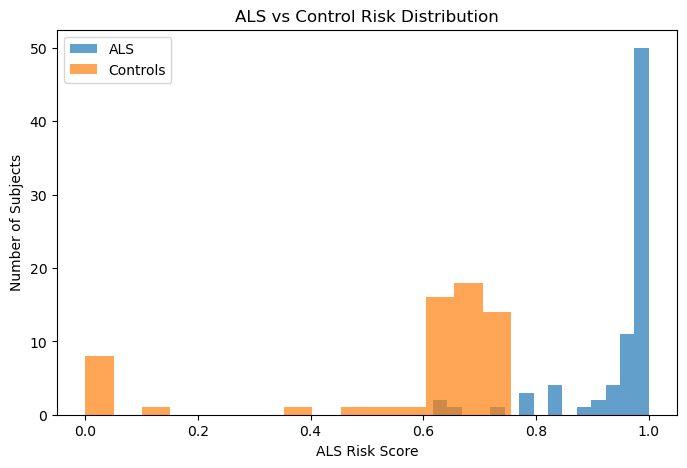

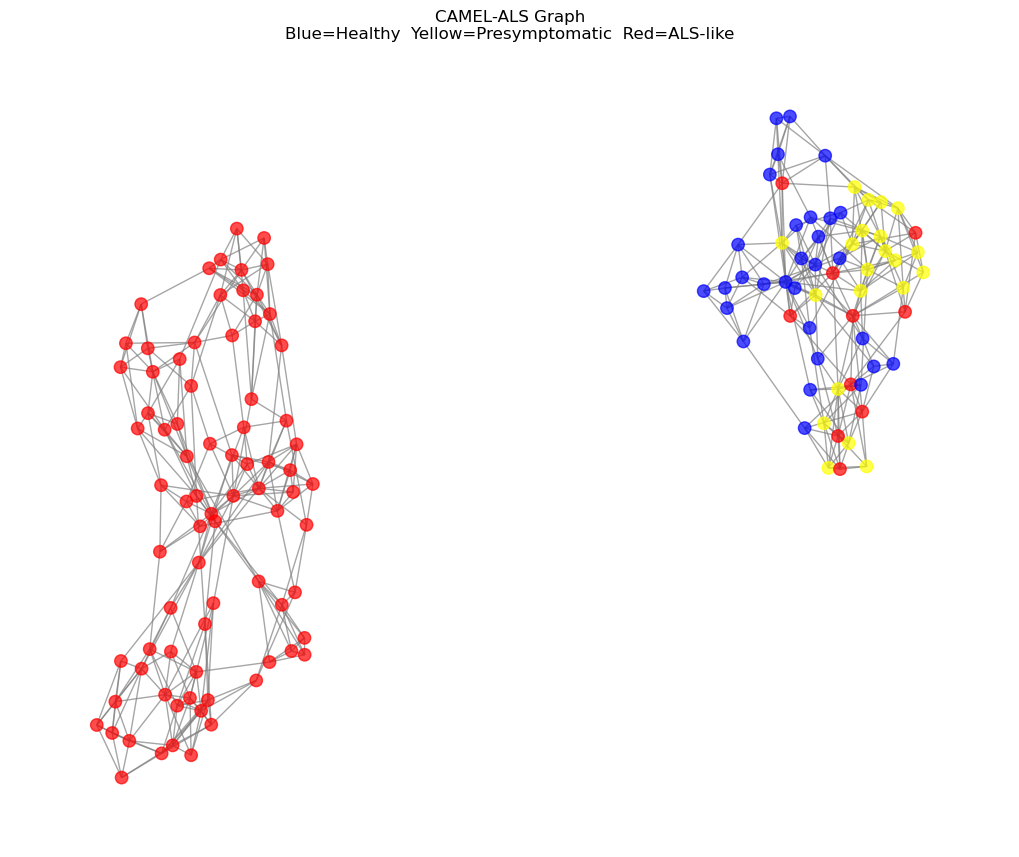

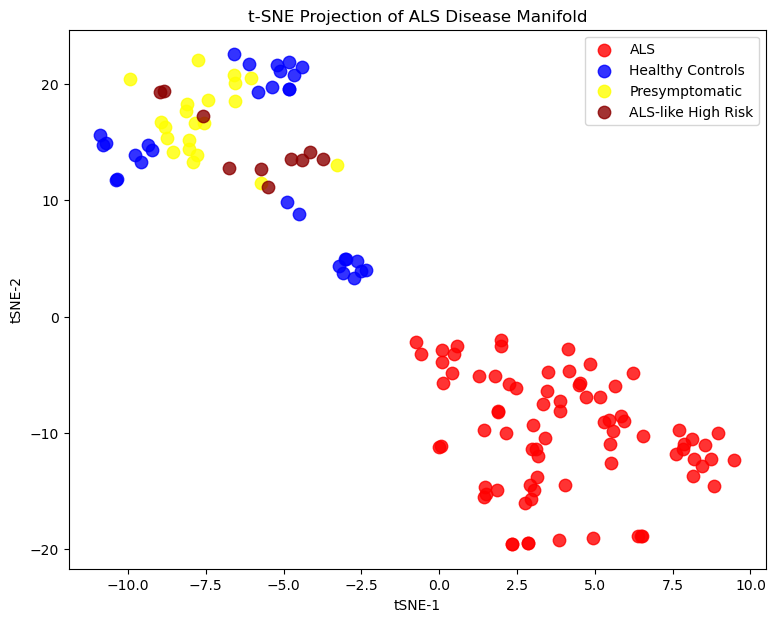

In [2]:
# ============================================================
# CAMEL-ALS VISUALIZATION BLOCK
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.manifold import TSNE

# ============================================================
# 1. RISK DISTRIBUTION HISTOGRAM
# ============================================================

als_risk = risk[:len(X_als_scaled)]
control_risk = risk[len(X_als_scaled):]

plt.figure(figsize=(8,5))

plt.hist(
    als_risk,
    bins=15,
    alpha=0.7,
    label="ALS",
)

plt.hist(
    control_risk,
    bins=15,
    alpha=0.7,
    label="Controls",
)

plt.xlabel("ALS Risk Score")
plt.ylabel("Number of Subjects")
plt.title("ALS vs Control Risk Distribution")
plt.legend()

plt.show()

# ============================================================
# 2. GRAPH VISUALIZATION COLORED BY CLINICAL STAGE
# ============================================================

# stage colors
# 0 = healthy (blue)
# 1 = presymptomatic (yellow)
# 2 = ALS-like (red)

node_colors = []

# ALS patients always red
for i in range(len(als_risk)):
    node_colors.append("red")

# controls by stage
for s in control_stage:

    if s == 0:
        node_colors.append("blue")

    elif s == 1:
        node_colors.append("yellow")

    else:
        node_colors.append("red")

# build graph
G = nx.Graph()

G.add_nodes_from(range(len(X_all)))
G.add_edges_from(edge_index.t().numpy())

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    node_size=80,
    edge_color="gray",
    alpha=0.7,
    with_labels=False
)

plt.title(
    "CAMEL-ALS Graph\n"
    "Blue=Healthy  Yellow=Presymptomatic  Red=ALS-like"
)

plt.show()


# ============================================================
# t-SNE EMBEDDING VISUALIZATION
# ============================================================

from sklearn.manifold import TSNE

embedding = z.detach().numpy()

tsne = TSNE(
    n_components=2,
    perplexity=20,
    random_state=42
)

tsne_2d = tsne.fit_transform(embedding)

plt.figure(figsize=(9,7))

# ALS
plt.scatter(
    tsne_2d[:len(als_risk), 0],
    tsne_2d[:len(als_risk), 1],
    c="red",
    s=80,
    alpha=0.8,
    label="ALS"
)

# Healthy Controls
healthy_idx = np.where(control_stage == 0)[0]

plt.scatter(
    tsne_2d[len(als_risk)+healthy_idx, 0],
    tsne_2d[len(als_risk)+healthy_idx, 1],
    c="blue",
    s=80,
    alpha=0.8,
    label="Healthy Controls"
)

# Presymptomatic
pre_idx = np.where(control_stage == 1)[0]

plt.scatter(
    tsne_2d[len(als_risk)+pre_idx, 0],
    tsne_2d[len(als_risk)+pre_idx, 1],
    c="yellow",
    s=80,
    alpha=0.8,
    label="Presymptomatic"
)

# ALS-like High Risk
high_idx = np.where(control_stage == 2)[0]

plt.scatter(
    tsne_2d[len(als_risk)+high_idx, 0],
    tsne_2d[len(als_risk)+high_idx, 1],
    c="darkred",
    s=80,
    alpha=0.8,
    label="ALS-like High Risk"
)

plt.title("t-SNE Projection of ALS Disease Manifold")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")

plt.legend()
plt.show()





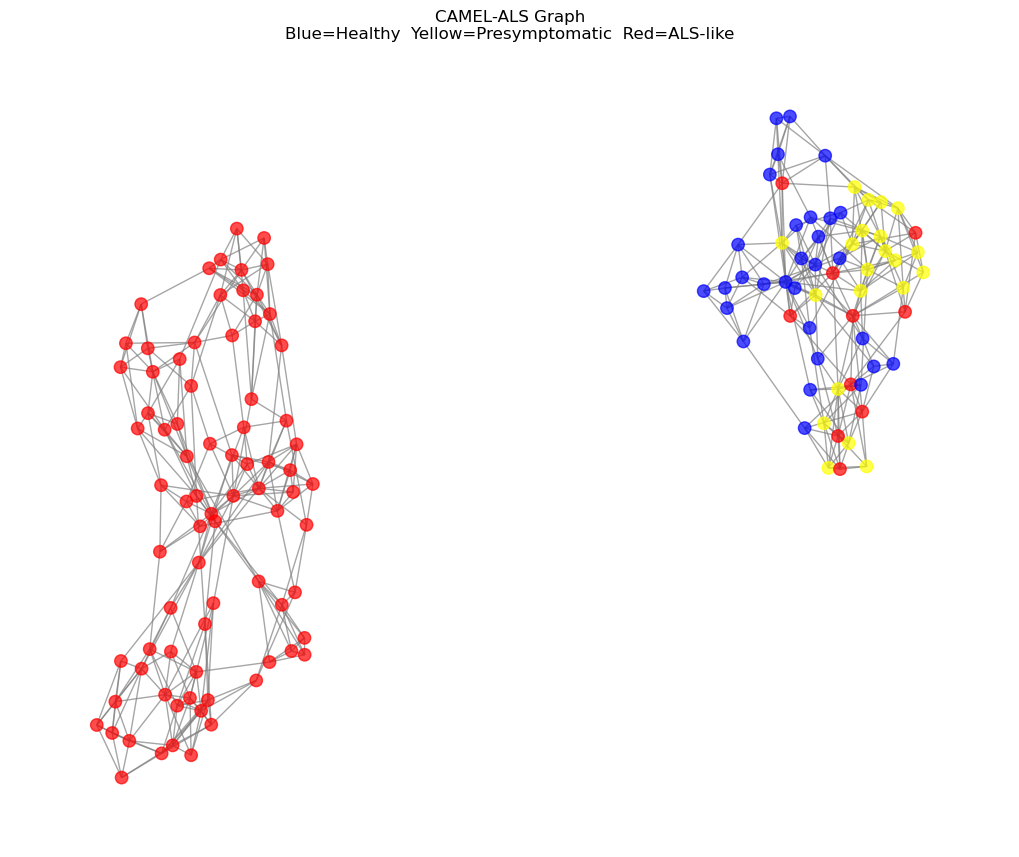

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.manifold import TSNE
# 2. GRAPH VISUALIZATION COLORED BY CLINICAL STAGE
# ============================================================

# stage colors
# 0 = healthy (blue)
# 1 = presymptomatic (yellow)
# 2 = ALS-like (red)

node_colors = []

# ALS patients always red
for i in range(len(als_risk)):
    node_colors.append("red")

# controls by stage
for s in control_stage:

    if s == 0:
        node_colors.append("blue")

    elif s == 1:
        node_colors.append("yellow")

    else:
        node_colors.append("red")

# build graph
G = nx.Graph()
G.add_nodes_from(range(len(X_all)))
G.add_edges_from(edge_index.t().numpy())

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    node_size=80,
    edge_color="gray",
    alpha=0.7,
    with_labels=False
)

plt.title(
    "CAMEL-ALS Graph\n"
    "Blue=Healthy  Yellow=Presymptomatic  Red=ALS-like"
)

plt.show()




Sample Pseudo-Time Progression Scores:

Subject 0: τ = 0.9035 (ALS)
Subject 1: τ = 0.9128 (ALS)
Subject 2: τ = 0.5728 (ALS)
Subject 3: τ = 0.7976 (ALS)
Subject 4: τ = 0.7060 (ALS)
Subject 5: τ = 0.9286 (ALS)
Subject 6: τ = 0.9614 (ALS)
Subject 7: τ = 0.9267 (ALS)
Subject 8: τ = 0.9059 (ALS)
Subject 9: τ = 0.7293 (ALS)
Subject 10: τ = 0.8860 (ALS)
Subject 11: τ = 0.9508 (ALS)
Subject 12: τ = 0.7743 (ALS)
Subject 13: τ = 0.7059 (ALS)
Subject 14: τ = 0.6013 (ALS)
Subject 15: τ = 0.9241 (ALS)
Subject 16: τ = 0.9298 (ALS)
Subject 17: τ = 0.8911 (ALS)
Subject 18: τ = 0.8931 (ALS)
Subject 19: τ = 0.9398 (ALS)
Subject 20: τ = 0.9185 (ALS)
Subject 21: τ = 0.6760 (ALS)
Subject 22: τ = 0.8956 (ALS)
Subject 23: τ = 0.9195 (ALS)
Subject 24: τ = 0.8956 (ALS)
Subject 25: τ = 0.9076 (ALS)
Subject 26: τ = 0.7549 (ALS)
Subject 27: τ = 0.8992 (ALS)
Subject 28: τ = 0.8994 (ALS)
Subject 29: τ = 0.8825 (ALS)
Subject 30: τ = 0.9330 (ALS)
Subject 31: τ = 0.9599 (ALS)
Subject 32: τ = 0.8781 (ALS)
Subject 33: 

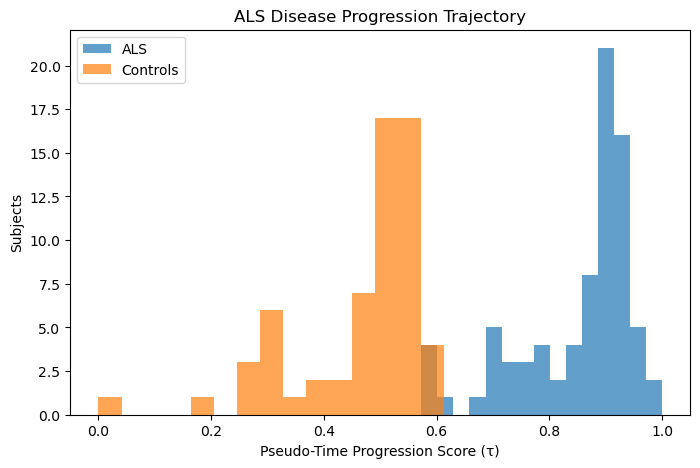

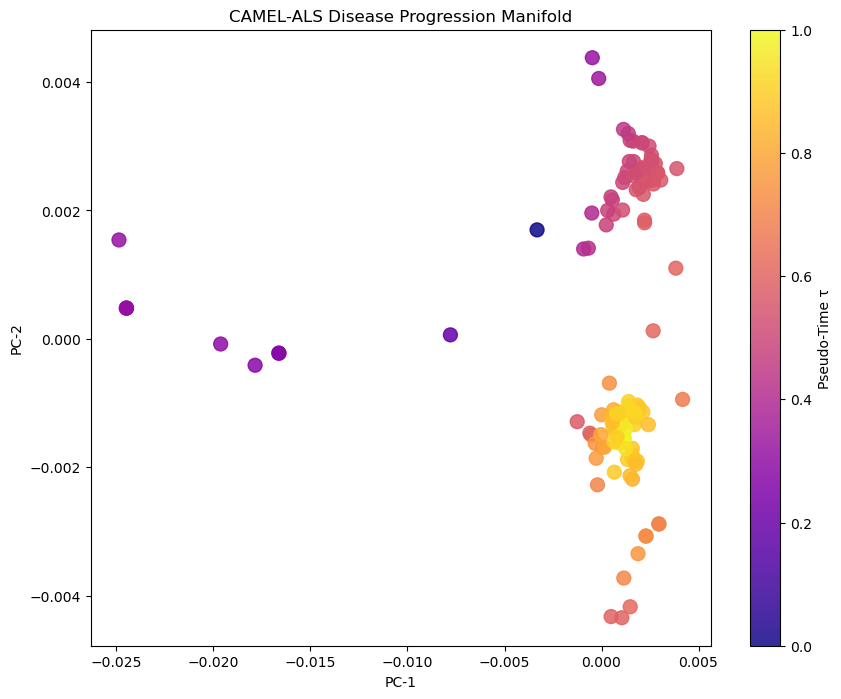

In [4]:
# ============================================================
# CAMEL-ALS PSEUDO-TIME PROGRESSION LEARNING
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

# ============================================================
# 1. GET EMBEDDINGS
# ============================================================

embedding = z.detach().numpy()

# ============================================================
# 2. DEFINE HEALTHY + ALS CENTROIDS
# ============================================================

als_embedding = embedding[:len(X_als_scaled)]

control_embedding = embedding[len(X_als_scaled):]

healthy_idx = np.where(control_stage == 0)[0]

healthy_embedding = control_embedding[healthy_idx]

# centroids
c_als = als_embedding.mean(axis=0).reshape(1, -1)

c_healthy = healthy_embedding.mean(axis=0).reshape(1, -1)

# ============================================================
# 3. COMPUTE PSEUDO-TIME
# ============================================================

d_healthy = euclidean_distances(embedding, c_healthy).flatten()

d_als = euclidean_distances(embedding, c_als).flatten()

tau = d_healthy / (d_healthy + d_als)

# normalize
tau = (tau - tau.min()) / (tau.max() - tau.min())

# ============================================================
# 4. PRINT SAMPLE TRAJECTORIES
# ============================================================

print("\nSample Pseudo-Time Progression Scores:\n")

for i in range(140):

    if i < len(X_als_scaled):
        label = "ALS"

    else:
        label = "CONTROL"

    print(f"Subject {i}: τ = {tau[i]:.4f} ({label})")
# ============================================================
# 7. CLINICAL INTERPRETATION
# ============================================================

print("\nClinical Progression Interpretation:\n")

for i in range(140):

    t = tau[i]

    if t < 0.3:
        stage = "Healthy"

    elif t < 0.6:
        stage = "Presymptomatic"

    else:
        stage = "ALS-like"

    print(f"Subject {i}: τ={t:.3f} → {stage}")
# ============================================================

# ============================================================
# 5. HISTOGRAM OF PROGRESSION
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    tau[:len(X_als_scaled)],
    bins=15,
    alpha=0.7,
    label="ALS"
)

plt.hist(
    tau[len(X_als_scaled):],
    bins=15,
    alpha=0.7,
    label="Controls"
)

plt.xlabel("Pseudo-Time Progression Score (τ)")
plt.ylabel("Subjects")

plt.title("ALS Disease Progression Trajectory")

plt.legend()

plt.show()
# 6. PCA TRAJECTORY VISUALIZATION
# ============================================================

pca = PCA(n_components=2)

pca_2d = pca.fit_transform(embedding)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    pca_2d[:,0],
    pca_2d[:,1],
    c=tau,
    cmap="plasma",
    s=100,
    alpha=0.85
)

plt.colorbar(scatter, label="Pseudo-Time τ")

plt.title("CAMEL-ALS Disease Progression Manifold")

plt.xlabel("PC-1")
plt.ylabel("PC-2")

plt.show()






In [5]:
# ============================================================
# FIND EARLY-STAGE ALS PATIENTS
# ============================================================

als_tau = tau[:len(X_als_scaled)]

# sort ALS patients by pseudo-time
sorted_idx = np.argsort(als_tau)

print("\nALS Patients with Lowest Pseudo-Time:\n")

for idx in sorted_idx[:10]:

    print(
        f"ALS Subject {idx} "
        f"→ τ = {als_tau[idx]:.4f}"
    )


ALS Patients with Lowest Pseudo-Time:

ALS Subject 2 → τ = 0.5728
ALS Subject 35 → τ = 0.5877
ALS Subject 62 → τ = 0.5964
ALS Subject 14 → τ = 0.6013
ALS Subject 41 → τ = 0.6186
ALS Subject 21 → τ = 0.6760
ALS Subject 50 → τ = 0.7022
ALS Subject 40 → τ = 0.7022
ALS Subject 13 → τ = 0.7059
ALS Subject 4 → τ = 0.7060


In [6]:
# ============================================================
# ALS PROGRESSION SUBGROUPS
# ============================================================

als_tau = tau[:len(X_als_scaled)]

early_als = np.where(als_tau < 0.6)[0]

late_als = np.where(als_tau >= 0.6)[0]

print("Early ALS subjects:", len(early_als))
print("Late ALS subjects:", len(late_als))

print("\nEarly ALS indices:\n")
print(early_als)

Early ALS subjects: 3
Late ALS subjects: 76

Early ALS indices:

[ 2 35 62]


In [7]:
# ============================================================
# EARLY vs LATE ALS BIOMARKER ANALYSIS
# ============================================================

# choose important features
features_to_check = X_als.columns[:10]

print("\nEARLY vs LATE ALS FEATURE COMPARISON\n")

for feature in features_to_check:

    early_mean = X_als.iloc[early_als][feature].mean()

    late_mean = X_als.iloc[late_als][feature].mean()

    print(f"{feature}")

    print(f"  Early ALS Mean : {early_mean:.4f}")

    print(f"  Late ALS Mean  : {late_mean:.4f}")

    print("-"*140)


EARLY vs LATE ALS FEATURE COMPARISON

Sentence Reading Mean Sentence Speaking Rate In Syll Per S
  Early ALS Mean : 2.5375
  Late ALS Mean  : 4.0141
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean Sent Articulation Rate In Syll Per S
  Early ALS Mean : 2.4216
  Late ALS Mean  : 0.9901
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean Sent Articulation Precision Ratio
  Early ALS Mean : -1.5470
  Late ALS Mean  : 2.7236
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean Sentence Pause Rate Ratio
  Early ALS Mean : 0.8743
  Late ALS Mean  : 2.7815
-----------------------------------------------------------------------------------------------------------

In [8]:
# ============================================================
# STATISTICAL VALIDATION
# ============================================================

from scipy.stats import ttest_ind

features_to_check = X_als.columns[:10]

print("\nSTATISTICAL COMPARISON\n")

for feature in features_to_check:

    early_vals = X_als.iloc[early_als][feature]

    late_vals = X_als.iloc[late_als][feature]

    t_stat, p_val = ttest_ind(
        early_vals,
        late_vals,
        equal_var=False
    )

    print(feature)

    print(f"p-value: {p_val:.5f}")

    if p_val < 0.05:
        print("Significant progression biomarker")

    else:
        print("Not significant")

    print("-"*140)


STATISTICAL COMPARISON

Sentence Reading Mean Sentence Speaking Rate In Syll Per S
p-value: 0.03979
Significant progression biomarker
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean Sent Articulation Rate In Syll Per S
p-value: 0.03603
Significant progression biomarker
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean Sent Articulation Precision Ratio
p-value: 0.16089
Not significant
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean Sentence Pause Rate Ratio
p-value: 0.12866
Not significant
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean

In [9]:
# ============================================================
# PSEUDO-TIME vs BIOMARKER CORRELATION
# ============================================================

from scipy.stats import spearmanr

als_tau = tau[:len(X_als_scaled)]

features_to_check = X_als.columns[:15]

print("\nPSEUDO-TIME CORRELATION ANALYSIS\n")

for feature in features_to_check:

    vals = X_als[feature]

    corr, p = spearmanr(als_tau, vals)

    print(feature)

    print(f"Spearman Correlation: {corr:.4f}")

    print(f"p-value: {p:.5f}")

    if p < 0.05:
        print("Significant progression relationship")

    else:
        print("Weak/non-significant relationship")

    print("-"*140)


PSEUDO-TIME CORRELATION ANALYSIS

Sentence Reading Mean Sentence Speaking Rate In Syll Per S
Spearman Correlation: 0.0638
p-value: 0.57635
Weak/non-significant relationship
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean Sent Articulation Rate In Syll Per S
Spearman Correlation: -0.1415
p-value: 0.21360
Weak/non-significant relationship
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean Sent Articulation Precision Ratio
Spearman Correlation: 0.1951
p-value: 0.08495
Weak/non-significant relationship
--------------------------------------------------------------------------------------------------------------------------------------------
Sentence Reading Mean Sentence Pause Rate Ratio
Spearman Correlation: 0.1938
p-value: 0.08707
Weak/non-significant relationship

Healthy controls: 30
Presymptomatic controls: 21

HEALTHY vs PRESYMPTOMATIC FEATURE ANALYSIS

                                              Feature  Healthy_Mean  \
2   Sentence Reading Mean Sent Articulation Precis...      3.415066   
4   Sentence Reading Mean Fixed Sent Voicing Regul...     20.412808   
27                                  Trial 2 Predicted  -1526.748316   
29                                  Trial 3 Predicted  -1559.351533   
3     Sentence Reading Mean Sentence Pause Rate Ratio      3.481802   
8   Sustained Phonation Min Phonation Pitch Instab...      0.753934   
24                                  Trial 1 Predicted  -1495.499169   
1   Sentence Reading Mean Sent Articulation Rate I...      1.002622   
0   Sentence Reading Mean Sentence Speaking Rate I...      3.432650   
6   Sustained Phonation Mean Phonation Total Dur P...      5.304413   
5    Sentence Reading Min Sentence Monotonicity In Hz     13.456194   
23                                     Trial 1 Result 

C:\Users\SNEHALATA ROUT\AppData\Local\Temp\ipykernel_22256\4144940053.py:121: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p = spearmanr(



TOP PRESYMPTOMATIC RISK FEATURES

                                              Feature  Importance
27                                  Trial 2 Predicted    0.687473
24                                  Trial 1 Predicted    0.050557
20                                          Age Years    0.025344
29                                  Trial 3 Predicted    0.017969
1   Sentence Reading Mean Sent Articulation Rate I...    0.016942
12  Story Recall Mean Immediate Story Recall Score...    0.015666
14  Picture Description Mean Image Descr Total Dur...    0.015069
5    Sentence Reading Min Sentence Monotonicity In Hz    0.013025
17  Picture Description Mean Spontaneous Lexical D...    0.012692
10  Category Naming Mean Cat Naming Verbal Fluency...    0.012354
18  Picture Description Mean Spontaneous Dbpi Dens...    0.012131
19  Picture Description Mean Image Descr Sem Relev...    0.012043
23                                     Trial 1 Result    0.011784
13  Story Recall Delayed Mean Delayed Sto

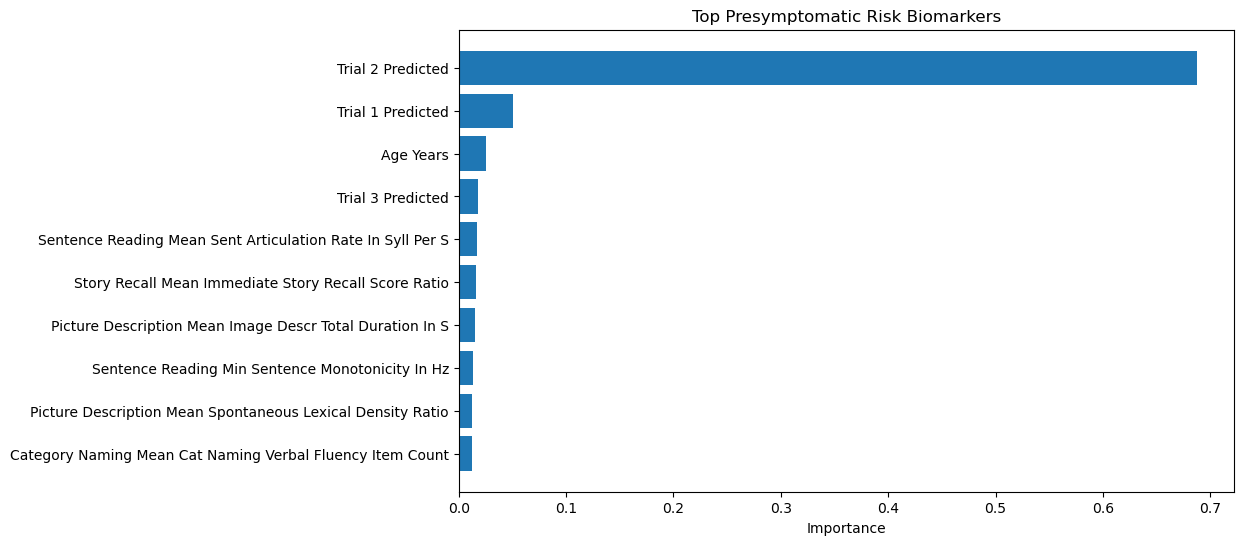

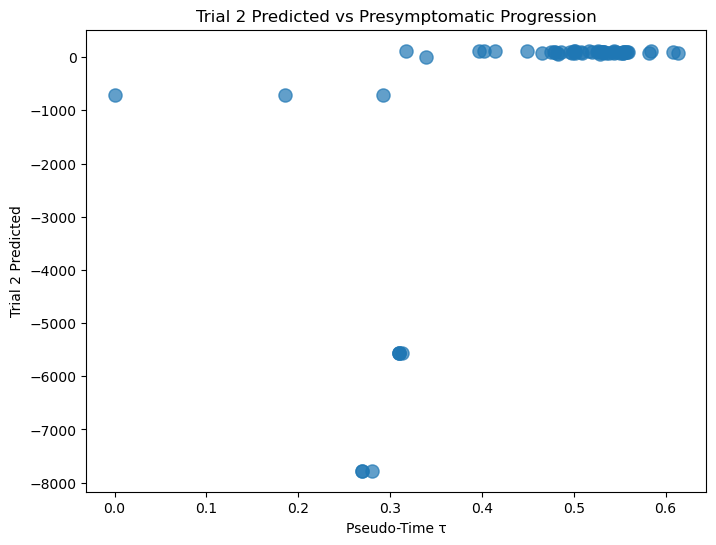


FINAL EARLY PRESYMPTOMATIC BIOMARKERS

1. Trial 2 Predicted (Importance=0.6875)
2. Trial 1 Predicted (Importance=0.0506)
3. Age Years (Importance=0.0253)
4. Trial 3 Predicted (Importance=0.0180)
5. Sentence Reading Mean Sent Articulation Rate In Syll Per S (Importance=0.0169)
6. Story Recall Mean Immediate Story Recall Score Ratio (Importance=0.0157)
7. Picture Description Mean Image Descr Total Duration In S (Importance=0.0151)
8. Sentence Reading Min Sentence Monotonicity In Hz (Importance=0.0130)
9. Picture Description Mean Spontaneous Lexical Density Ratio (Importance=0.0127)
10. Category Naming Mean Cat Naming Verbal Fluency Item Count (Importance=0.0124)


In [10]:
# ============================================================
# PRESYMPTOMATIC FEATURE DISCOVERY
# Identify biomarkers driving presymptomatic risk
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, ttest_ind
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# ============================================================
# 1. DEFINE CONTROL GROUPS
# ============================================================

# control pseudo-time
control_tau = tau[len(X_als):]

# control feature matrix
X_control_full = X_control.copy()

# presymptomatic controls
pre_idx = np.where(control_stage == 1)[0]

# healthy controls
healthy_idx = np.where(control_stage == 0)[0]

print("Healthy controls:", len(healthy_idx))
print("Presymptomatic controls:", len(pre_idx))

# ============================================================
# 2. HEALTHY vs PRESYMPTOMATIC COMPARISON
# ============================================================

results = []

print("\n================================================")
print("HEALTHY vs PRESYMPTOMATIC FEATURE ANALYSIS")
print("================================================\n")

for feature in X_control_full.columns:

    healthy_vals = X_control_full.iloc[
        healthy_idx
    ][feature]

    pre_vals = X_control_full.iloc[
        pre_idx
    ][feature]

    # t-test
    t_stat, p_val = ttest_ind(
        healthy_vals,
        pre_vals,
        equal_var=False
    )

    # effect size
    effect = (
        pre_vals.mean() -
        healthy_vals.mean()
    )

    results.append([
        feature,
        healthy_vals.mean(),
        pre_vals.mean(),
        effect,
        p_val
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "Healthy_Mean",
        "Presymptomatic_Mean",
        "Effect_Size",
        "P_Value"
    ]
)

# ============================================================
# 3. SORT MOST IMPORTANT FEATURES
# ============================================================

results_df = results_df.sort_values(
    by="P_Value"
)

print(results_df.head(15))

# ============================================================
# 4. SIGNIFICANT FEATURES
# ============================================================

significant = results_df[
    results_df["P_Value"] < 0.05
]

print("\n================================================")
print("SIGNIFICANT PRESYMPTOMATIC FEATURES")
print("================================================\n")

print(significant)

# ============================================================
# 5. CORRELATION WITH PSEUDO-TIME
# ============================================================

corr_results = []

print("\n================================================")
print("PSEUDO-TIME CORRELATION")
print("================================================\n")

for feature in X_control_full.columns:

    corr, p = spearmanr(
        control_tau,
        X_control_full[feature]
    )

    corr_results.append([
        feature,
        corr,
        p
    ])

corr_df = pd.DataFrame(
    corr_results,
    columns=[
        "Feature",
        "Spearman_r",
        "P_Value"
    ]
)

corr_df = corr_df.sort_values(
    by="P_Value"
)

print(corr_df.head(15))

# ============================================================
# 6. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_control_full,
    control_tau
)

importance_df = pd.DataFrame({

    "Feature": X_control_full.columns,

    "Importance": rf.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n================================================")
print("TOP PRESYMPTOMATIC RISK FEATURES")
print("================================================\n")

print(importance_df.head(15))

# ============================================================
# 7. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(

    rf,

    X_control_full,

    control_tau,

    n_repeats=10,

    random_state=42

)

perm_df = pd.DataFrame({

    "Feature": X_control_full.columns,

    "Permutation_Importance": perm.importances_mean

})

perm_df = perm_df.sort_values(

    by="Permutation_Importance",

    ascending=False
)

print("\n================================================")
print("PERMUTATION IMPORTANCE")
print("================================================\n")

print(perm_df.head(15))

# ============================================================
# 8. VISUALIZE TOP FEATURES
# ============================================================

top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(

    top_features["Feature"],

    top_features["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title(
    "Top Presymptomatic Risk Biomarkers"
)

plt.show()

# ============================================================
# 9. VISUALIZE BEST BIOMARKER vs PSEUDO-TIME
# ============================================================

best_feature = importance_df.iloc[0]["Feature"]

plt.figure(figsize=(8,6))

plt.scatter(

    control_tau,

    X_control_full[best_feature],

    s=90,

    alpha=0.7

)

plt.xlabel("Pseudo-Time τ")

plt.ylabel(best_feature)

plt.title(
    f"{best_feature} vs Presymptomatic Progression"
)

plt.show()

# ============================================================
# 10. PRINT FINAL BIOMARKERS
# ============================================================

print("\n================================================")
print("FINAL EARLY PRESYMPTOMATIC BIOMARKERS")
print("================================================\n")

for i in range(10):

    row = importance_df.iloc[i]

    print(
        f"{i+1}. "
        f"{row['Feature']} "
        f"(Importance={row['Importance']:.4f})"
    )
